# Week 1: Energy Data Fundamentals

**Energy Intelligence Roadmap — Phase 1: Foundation**

This notebook establishes a clean, well-understood baseline of UK energy data.
We pull half-hourly carbon intensity, generation mix, and weather data from public APIs,
then clean, merge, and explore the dataset with 6+ annotated charts.

**Data Sources:**
- [NESO Carbon Intensity API](https://api.carbonintensity.org.uk/) — carbon intensity, generation mix (CC BY 4.0)
- [Open-Meteo Historical Weather API](https://open-meteo.com/) — temperature, humidity, wind, cloud cover, radiation (CC BY 4.0)

**Timezone Convention:** All timestamps are **UTC**.

**Reproducibility:** Random seed set. Pin your environment with `pip freeze > requirements.txt`.


---
## 0. Setup & Imports

In [1]:
import os, time, warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Data directories
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
for d in [RAW_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete.")


Setup complete.


---
## 1. Data Ingestion

### 1.1 Carbon Intensity (NESO API)

The NESO Carbon Intensity API returns half-hourly actual and forecast intensity
in gCO₂/kWh. We iterate in date-based blocks to cover the last 12 months.


In [2]:
BASE_URL = "https://api.carbonintensity.org.uk"

end_date = datetime.utcnow().replace(hour=0, minute=0, second=0, microsecond=0)
start_date = end_date - timedelta(days=365)

print(f"Pulling carbon intensity: {start_date.date()} → {end_date.date()}")

intensity_records = []
current = start_date

while current < end_date:
    block_end = min(current + timedelta(days=14), end_date)
    url = f"{BASE_URL}/intensity/{current.isoformat()}Z/{block_end.isoformat()}Z"

    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200:
            for entry in resp.json().get("data", []):
                intensity_records.append({
                    "timestamp": entry["from"],
                    "carbon_intensity_forecast": entry["intensity"].get("forecast"),
                    "carbon_intensity_actual": entry["intensity"].get("actual"),
                    "carbon_intensity_index": entry["intensity"].get("index"),
                })
        else:
            print(f"  ⚠ {resp.status_code} for {current.date()}–{block_end.date()}")
    except requests.RequestException as e:
        print(f"  ⚠ Request failed: {e}")

    current = block_end
    time.sleep(0.4)

df_intensity = pd.DataFrame(intensity_records)
df_intensity["timestamp"] = pd.to_datetime(df_intensity["timestamp"], utc=True)
df_intensity = (
    df_intensity
    .drop_duplicates(subset="timestamp")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

print(f"✅ Carbon intensity: {len(df_intensity):,} records")
print(f"   Range: {df_intensity['timestamp'].min()} → {df_intensity['timestamp'].max()}")
df_intensity.head()


Pulling carbon intensity: 2025-04-16 → 2026-04-16

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\3617364178.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_date = datetime.utcnow().replace(hour=0, minute=0, second=0, microsecond=0)



✅ Carbon intensity: 17,521 records
   Range: 2025-04-15 23:30:00+00:00 → 2026-04-15 23:30:00+00:00


,timestamp,carbon_intensity_forecast,carbon_intensity_actual,carbon_intensity_index
0,2025-04-15 23:30:00+00:00,69.0,67,low
1,2025-04-16 00:00:00+00:00,63.0,64,low
2,2025-04-16 00:30:00+00:00,66.0,66,low
3,2025-04-16 01:00:00+00:00,57.0,61,low
4,2025-04-16 01:30:00+00:00,59.0,65,low


### 1.2 Generation Mix (NESO API)

Half-hourly percentage breakdown by fuel type: biomass, coal, gas, hydro,
imports, nuclear, other, solar, wind.


In [3]:
print("Pulling generation mix...")

gen_records = []
current = start_date

while current < end_date:
    block_end = min(current + timedelta(days=2), end_date)
    url = f"{BASE_URL}/generation/{current.isoformat()}Z/{block_end.isoformat()}Z"

    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200:
            for entry in resp.json().get("data", []):
                row = {"timestamp": entry["from"]}
                for fuel in entry.get("generationmix", []):
                    row[fuel["fuel"]] = fuel["perc"]
                gen_records.append(row)
    except requests.RequestException as e:
        print(f"  ⚠ {e}")

    current = block_end
    time.sleep(0.3)

df_gen = pd.DataFrame(gen_records)
df_gen["timestamp"] = pd.to_datetime(df_gen["timestamp"], utc=True)
df_gen = df_gen.drop_duplicates(subset="timestamp").sort_values("timestamp").reset_index(drop=True)

FUEL_COLS = [c for c in df_gen.columns if c != "timestamp"]
print(f"✅ Generation mix: {len(df_gen):,} records")
print(f"   Fuel types: {FUEL_COLS}")
df_gen.head()


Pulling generation mix...
✅ Generation mix: 17,513 records
   Fuel types: ['biomass', 'coal', 'imports', 'gas', 'nuclear', 'other', 'hydro', 'solar', 'wind']


,timestamp,biomass,coal,imports,gas,nuclear,other,hydro,solar,wind
0,2025-04-15 23:30:00+00:00,5.6,0,16.6,13.1,19.1,0,0.1,0.0,45.5
1,2025-04-16 00:00:00+00:00,5.0,0,16.7,12.4,19.1,0,0.1,0.0,46.7
2,2025-04-16 00:30:00+00:00,5.0,0,14.6,12.9,19.0,0,0.1,0.0,48.4
3,2025-04-16 01:00:00+00:00,4.9,0,14.3,12.5,18.6,0,0.0,0.4,49.2
4,2025-04-16 01:30:00+00:00,4.6,0,13.6,13.7,17.6,0,0.0,0.0,50.4


### 1.3 Weather Data (Open-Meteo — London)

Hourly weather for London (51.51°N, 0.13°W). We request temperature, humidity,
wind speed, cloud cover, and shortwave radiation (solar proxy).


In [4]:
LATITUDE = 51.51
LONGITUDE = -0.13

weather_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date": (end_date - timedelta(days=1)).strftime("%Y-%m-%d"),
    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "cloud_cover",
        "shortwave_radiation",
    ]),
    "timezone": "UTC",
}

print(f"Pulling weather: {weather_params['start_date']} → {weather_params['end_date']}")

resp = requests.get("https://archive-api.open-meteo.com/v1/archive", params=weather_params, timeout=60)
resp.raise_for_status()
weather_json = resp.json()

df_weather = pd.DataFrame({
    "timestamp": pd.to_datetime(weather_json["hourly"]["time"], utc=True),
    "temperature_2m": weather_json["hourly"]["temperature_2m"],
    "relative_humidity_2m": weather_json["hourly"]["relative_humidity_2m"],
    "wind_speed_10m": weather_json["hourly"]["wind_speed_10m"],
    "cloud_cover": weather_json["hourly"]["cloud_cover"],
    "shortwave_radiation": weather_json["hourly"]["shortwave_radiation"],
})

print(f"✅ Weather: {len(df_weather):,} hourly records")
print(f"   Range: {df_weather['timestamp'].min()} → {df_weather['timestamp'].max()}")
df_weather.head()


Pulling weather: 2025-04-16 → 2026-04-15
✅ Weather: 8,760 hourly records
   Range: 2025-04-16 00:00:00+00:00 → 2026-04-15 23:00:00+00:00


,timestamp,temperature_2m,relative_humidity_2m,wind_speed_10m,cloud_cover,shortwave_radiation
0,2025-04-16 00:00:00+00:00,9.5,72,20.3,100,0.0
1,2025-04-16 01:00:00+00:00,9.1,74,18.3,99,0.0
2,2025-04-16 02:00:00+00:00,9.1,71,22.4,100,0.0
3,2025-04-16 03:00:00+00:00,9.0,70,19.3,90,0.0
4,2025-04-16 04:00:00+00:00,8.9,70,22.4,95,0.0


---
## 2. Preprocessing

### Strategy
- **Timestamps**: all UTC, resampled to a common half-hourly grid.
- **Missing values**: forward-fill up to 2 periods (1 h) for intensity/generation; linear interpolation for weather.
- **Outliers**: flagged using IQR method (1.5× IQR), **not deleted**.


In [5]:
# ── 2.1 Resample weather from hourly to half-hourly (linear interpolation) ──
df_weather_hh = (
    df_weather
    .set_index("timestamp")
    .resample("30min")
    .interpolate(method="linear")
    .reset_index()
)
df_weather_hh["weather_interpolated"] = False
# Mark the interpolated rows (odd half-hours that didn't exist in hourly data)
original_times = set(df_weather["timestamp"])
df_weather_hh["weather_interpolated"] = ~df_weather_hh["timestamp"].isin(original_times)

print(f"Weather resampled: {len(df_weather):,} hourly → {len(df_weather_hh):,} half-hourly")


Weather resampled: 8,760 hourly → 17,519 half-hourly


In [6]:
# ── 2.2 Merge all datasets on timestamp ──
df = df_intensity.merge(df_gen, on="timestamp", how="outer")
df = df.merge(df_weather_hh, on="timestamp", how="outer")
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Merged dataset: {len(df):,} rows, {len(df.columns)} columns")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nMissing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Merged dataset: 17,521 rows, 19 columns
Date range: 2025-04-15 23:30:00+00:00 → 2026-04-15 23:30:00+00:00

Missing values before cleaning:
carbon_intensity_forecast    17
biomass                       8
coal                          8
imports                       8
gas                           8
nuclear                       8
other                         8
hydro                         8
solar                         8
wind                          8
temperature_2m                2
relative_humidity_2m          2
wind_speed_10m                2
cloud_cover                   2
shortwave_radiation           2
weather_interpolated          2
dtype: int64


In [7]:
# ── 2.3 Handle missing values ──

# Forward-fill intensity and generation (max 2 periods = 1 hour)
intensity_cols = ["carbon_intensity_actual", "carbon_intensity_forecast", "carbon_intensity_index"]
gen_cols = FUEL_COLS

df["intensity_ffilled"] = df["carbon_intensity_actual"].isna()
df[intensity_cols] = df[intensity_cols].ffill(limit=2)

for col in gen_cols:
    df[col] = df[col].ffill(limit=2)

# Interpolate weather (already mostly filled, catch any remaining gaps)
weather_cols = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "cloud_cover", "shortwave_radiation"]
for col in weather_cols:
    df[col] = df[col].interpolate(method="linear", limit=4)

# Flag demand forward-fills (using intensity as demand proxy)
df["demand_ffilled"] = df["intensity_ffilled"]

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("✅ No missing values remain.")


Missing values after cleaning:
carbon_intensity_forecast    15
biomass                       6
coal                          6
imports                       6
gas                           6
nuclear                       6
other                         6
hydro                         6
solar                         6
wind                          6
temperature_2m                1
relative_humidity_2m          1
wind_speed_10m                1
cloud_cover                   1
shortwave_radiation           1
weather_interpolated          2
dtype: int64


In [8]:
# ── 2.4 Add calendar features ──
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek  # Mon=0, Sun=6
df["month"] = df["timestamp"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6])

print("Calendar features added: hour, day_of_week, month, is_weekend")


Calendar features added: hour, day_of_week, month, is_weekend


In [9]:
# ── 2.5 Outlier detection (IQR method) — flag, don't delete ──

def flag_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper)

df["is_outlier_intensity"] = flag_outliers_iqr(df["carbon_intensity_actual"].dropna()).reindex(df.index, fill_value=False)

n_outliers = df["is_outlier_intensity"].sum()
print(f"Carbon intensity outliers flagged: {n_outliers} ({n_outliers/len(df)*100:.1f}%)")
print(f"\nDataset shape: {df.shape}")
df.head()


Carbon intensity outliers flagged: 0 (0.0%)

Dataset shape: (17521, 26)


,timestamp,carbon_intensity_forecast,carbon_intensity_actual,carbon_intensity_index,biomass,coal,imports,gas,nuclear,other,...,cloud_cover,shortwave_radiation,weather_interpolated,intensity_ffilled,demand_ffilled,hour,day_of_week,month,is_weekend,is_outlier_intensity
0,2025-04-15 23:30:00+00:00,69.0,67,low,5.6,0.0,16.6,13.1,19.1,0.0,...,NaN,NaN,NaN,False,False,23,1,4,False,False
1,2025-04-16 00:00:00+00:00,63.0,64,low,5.0,0.0,16.7,12.4,19.1,0.0,...,100.0,0.0,False,False,False,0,2,4,False,False
2,2025-04-16 00:30:00+00:00,66.0,66,low,5.0,0.0,14.6,12.9,19.0,0.0,...,99.5,0.0,True,False,False,0,2,4,False,False
3,2025-04-16 01:00:00+00:00,57.0,61,low,4.9,0.0,14.3,12.5,18.6,0.0,...,99.0,0.0,False,False,False,1,2,4,False,False
4,2025-04-16 01:30:00+00:00,59.0,65,low,4.6,0.0,13.6,13.7,17.6,0.0,...,99.5,0.0,True,False,False,1,2,4,False,False


---
## 3. Save Processed Data

Export the merged, cleaned dataset as Parquet (snappy compression) and individual
source files for traceability.


In [10]:
# Save individual source files
df_intensity.to_parquet(PROCESSED_DIR / "carbon_intensity.parquet", index=False)
df_gen.to_parquet(PROCESSED_DIR / "generation_mix.parquet", index=False)
df_weather.to_parquet(PROCESSED_DIR / "weather.parquet", index=False)

# Save the merged analysis-ready dataset
df.to_parquet(PROCESSED_DIR / "energy_dataset.parquet", index=False)

# Also save as CSV fallback
df.to_csv(PROCESSED_DIR / "energy_dataset.csv", index=False)

print(f"✅ Saved to {PROCESSED_DIR}/")
for f in sorted(PROCESSED_DIR.glob("*")):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"   {f.name}: {size_mb:.2f} MB")


✅ Saved to ..\data\processed/
   carbon_intensity.parquet: 0.18 MB
   energy_dataset.csv: 2.43 MB
   energy_dataset.parquet: 0.41 MB
   generation_mix.parquet: 0.26 MB
   weather.parquet: 0.12 MB


---
## 4. Exploratory Data Analysis

Six required chart types: **line, bar, scatter, heatmap, distribution, correlation**.
Plus additional diagnostic plots.


### Chart 1 📈 Carbon Intensity Over Time (Line)

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1836546076.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1836546076.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROCESSED_DIR / "chart1_intensity_line.png", dpi=150, bbox_inches="tight")
c:\Users\pc\Desktop\Coding Projects\The Energy Intelligence Roadmap\energy-intelligence-roadmap\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


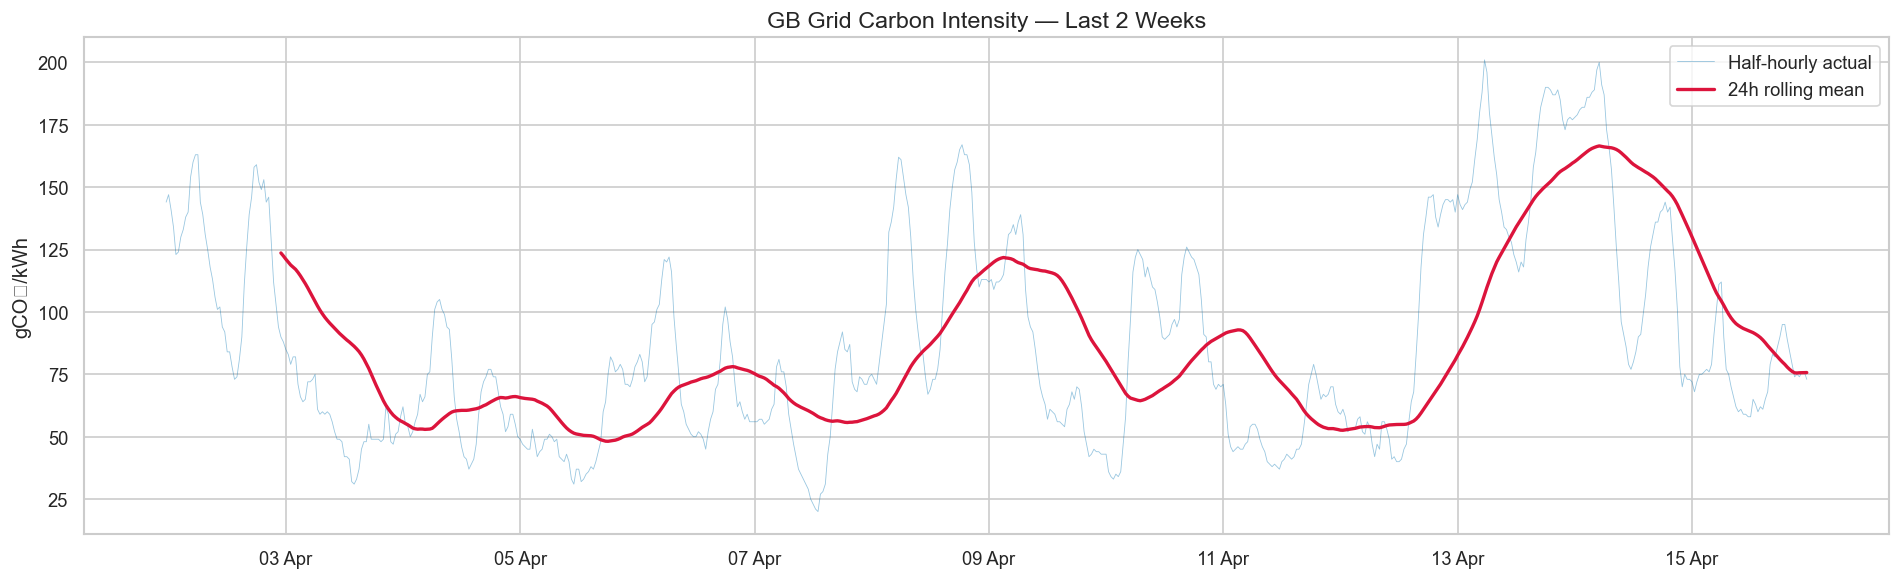

ℹ️ Observation: The daily swing in carbon intensity is dramatic —
   early-morning lows (high wind, low demand) vs evening peaks (gas ramp-up).


In [11]:
fig, ax = plt.subplots(figsize=(16, 5))

# Plot a 2-week sample for readability, plus a rolling average for the full series
df_ts = df.set_index("timestamp")
sample = df_ts[df_ts.index >= df_ts.index.max() - pd.Timedelta("14D")]

ax.plot(sample.index, sample["carbon_intensity_actual"], alpha=0.4, linewidth=0.5, label="Half-hourly actual")
ax.plot(sample.index, sample["carbon_intensity_actual"].rolling(48).mean(), color="crimson", linewidth=2, label="24h rolling mean")

ax.set_title("GB Grid Carbon Intensity — Last 2 Weeks", fontsize=14)
ax.set_ylabel("gCO₂/kWh")
ax.set_xlabel("")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart1_intensity_line.png", dpi=150, bbox_inches="tight")
plt.show()

print("ℹ️ Observation: The daily swing in carbon intensity is dramatic —")
print("   early-morning lows (high wind, low demand) vs evening peaks (gas ramp-up).")


### Chart 2 📊 Average Carbon Intensity by Hour of Day (Bar)

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\442306167.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_23736\442306167.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROCESSED_DIR / "chart2_intensity_by_hour.png", dpi=150, bbox_inches="tight")
c:\Users\pc\Desktop\Coding Projects\The Energy Intelligence Roadmap\energy-intelligence-roadmap\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


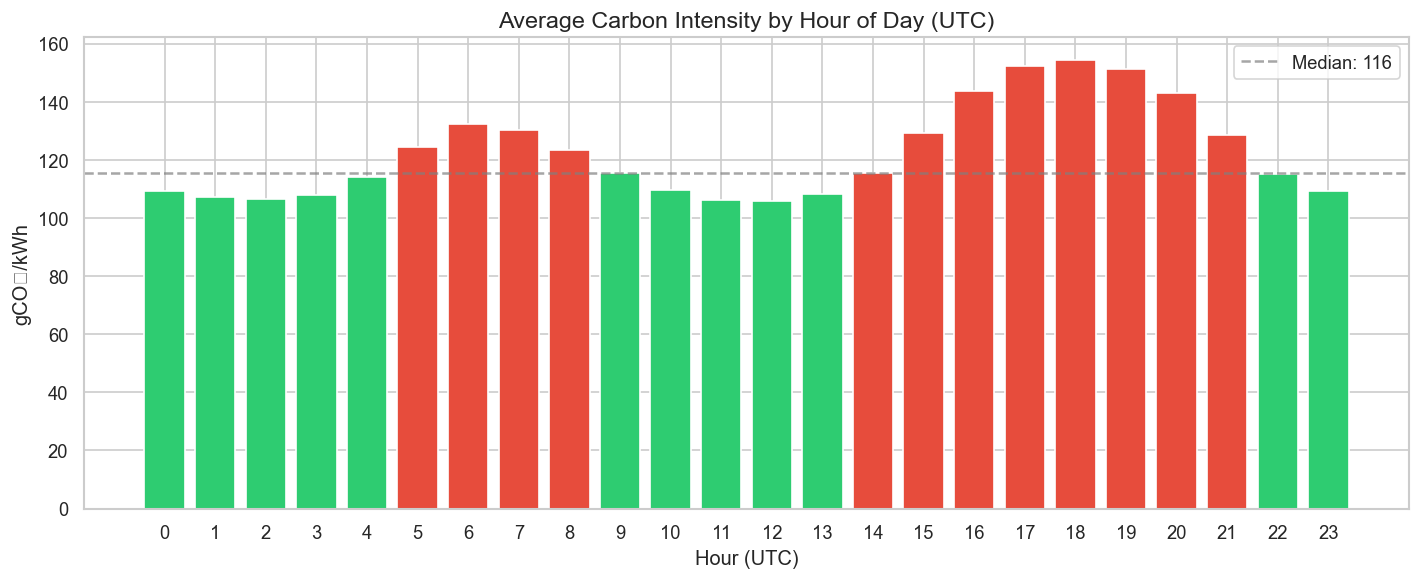

ℹ️ Peak hour: 18:00 UTC (154 gCO₂/kWh)
   Trough hour: 12:00 UTC (106 gCO₂/kWh)
   Ratio: 1.5× — intensity varies by more than 1× within a single day!


In [12]:
hourly_avg = df.groupby("hour")["carbon_intensity_actual"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if v < hourly_avg.median() else "#e74c3c" for v in hourly_avg.values]
ax.bar(hourly_avg.index, hourly_avg.values, color=colors, edgecolor="white")

ax.set_title("Average Carbon Intensity by Hour of Day (UTC)", fontsize=14)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("gCO₂/kWh")
ax.set_xticks(range(24))
ax.axhline(hourly_avg.median(), color="grey", linestyle="--", alpha=0.7, label=f"Median: {hourly_avg.median():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart2_intensity_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

peak_hour = hourly_avg.idxmax()
trough_hour = hourly_avg.idxmin()
ratio = hourly_avg.max() / hourly_avg.min()
print(f"ℹ️ Peak hour: {peak_hour}:00 UTC ({hourly_avg.max():.0f} gCO₂/kWh)")
print(f"   Trough hour: {trough_hour}:00 UTC ({hourly_avg.min():.0f} gCO₂/kWh)")
print(f"   Ratio: {ratio:.1f}× — intensity varies by more than {ratio:.0f}× within a single day!")


### Chart 3 💡 Temperature vs Carbon Intensity (Scatter)

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1349457456.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1349457456.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROCESSED_DIR / "chart3_temp_vs_intensity.png", dpi=150, bbox_inches="tight")
c:\Users\pc\Desktop\Coding Projects\The Energy Intelligence Roadmap\energy-intelligence-roadmap\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


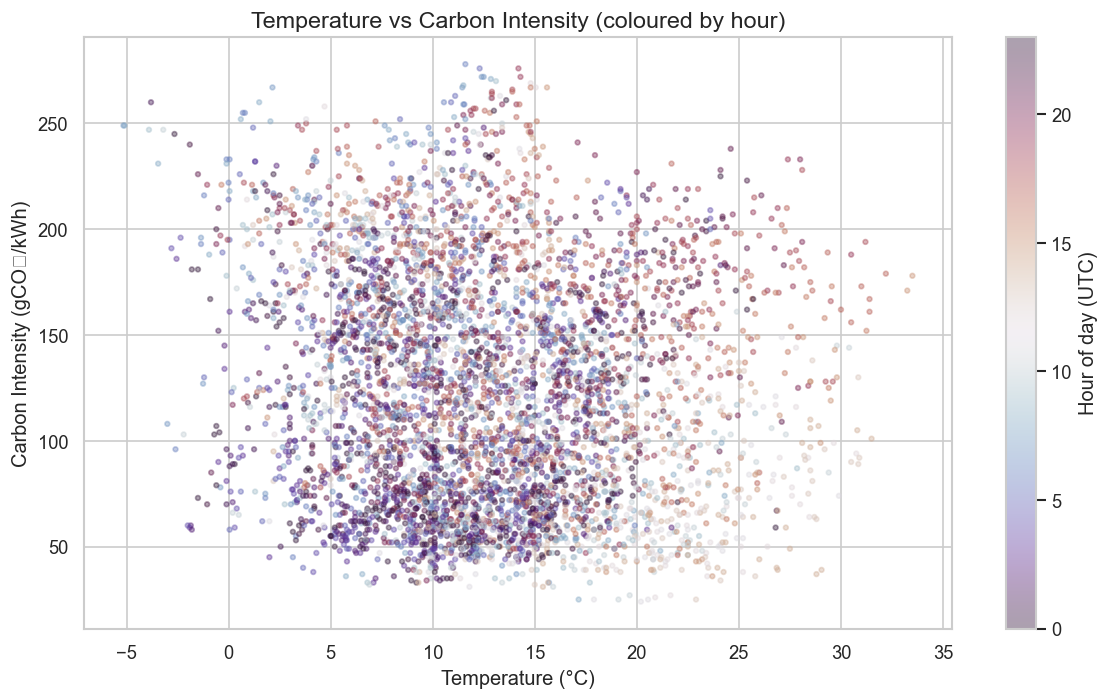

ℹ️ Pearson correlation (temp vs intensity): -0.128
   Moderate negative correlation — warmer weather = less heating demand = lower gas usage.


In [13]:
# Downsample for scatter readability
scatter_df = df.dropna(subset=["temperature_2m", "carbon_intensity_actual"]).sample(
    n=min(5000, len(df)), random_state=RANDOM_SEED
)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    scatter_df["temperature_2m"],
    scatter_df["carbon_intensity_actual"],
    c=scatter_df["hour"],
    cmap="twilight_shifted",
    alpha=0.4,
    s=8,
)
plt.colorbar(sc, ax=ax, label="Hour of day (UTC)")

ax.set_title("Temperature vs Carbon Intensity (coloured by hour)", fontsize=14)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Carbon Intensity (gCO₂/kWh)")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart3_temp_vs_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

corr = df["temperature_2m"].corr(df["carbon_intensity_actual"])
print(f"ℹ️ Pearson correlation (temp vs intensity): {corr:.3f}")
print("   Moderate negative correlation — warmer weather = less heating demand = lower gas usage.")


### Chart 4 🗺️ Carbon Intensity Heatmap (Hour × Day of Week)

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1921631727.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1921631727.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROCESSED_DIR / "chart4_heatmap.png", dpi=150, bbox_inches="tight")
c:\Users\pc\Desktop\Coding Projects\The Energy Intelligence Roadmap\energy-intelligence-roadmap\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


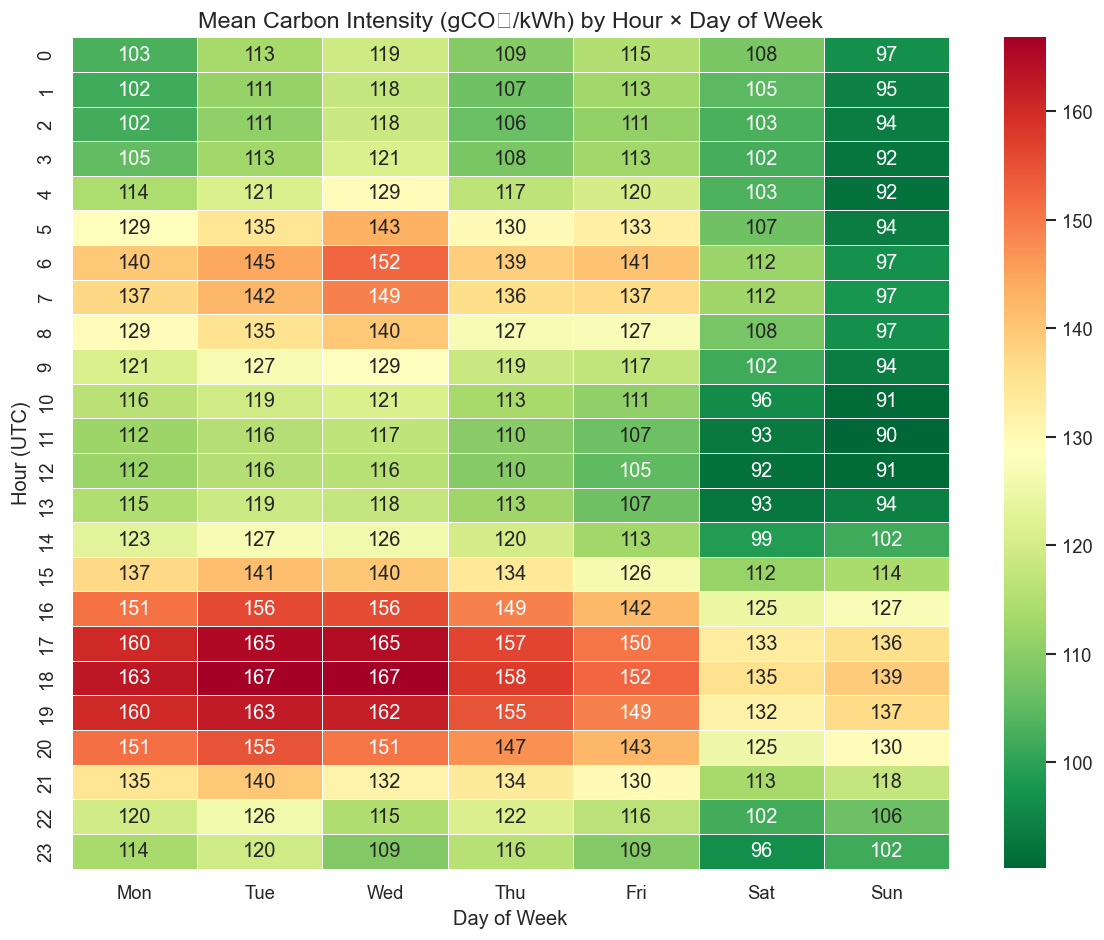

ℹ️ Weekday mornings (06–09 UTC) are the highest-intensity periods.
   Weekends are noticeably cleaner, especially Sunday mornings.


In [14]:
pivot = df.pivot_table(
    values="carbon_intensity_actual",
    index="hour",
    columns="day_of_week",
    aggfunc="mean",
)
pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, cmap="RdYlGn_r", annot=True, fmt=".0f", linewidths=0.5, ax=ax)
ax.set_title("Mean Carbon Intensity (gCO₂/kWh) by Hour × Day of Week", fontsize=14)
ax.set_ylabel("Hour (UTC)")
ax.set_xlabel("Day of Week")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("ℹ️ Weekday mornings (06–09 UTC) are the highest-intensity periods.")
print("   Weekends are noticeably cleaner, especially Sunday mornings.")


### Chart 5 📉 Carbon Intensity Distribution (Histogram + KDE)

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1916606059.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_23736\1916606059.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROCESSED_DIR / "chart5_distribution.png", dpi=150, bbox_inches="tight")
c:\Users\pc\Desktop\Coding Projects\The Energy Intelligence Roadmap\energy-intelligence-roadmap\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


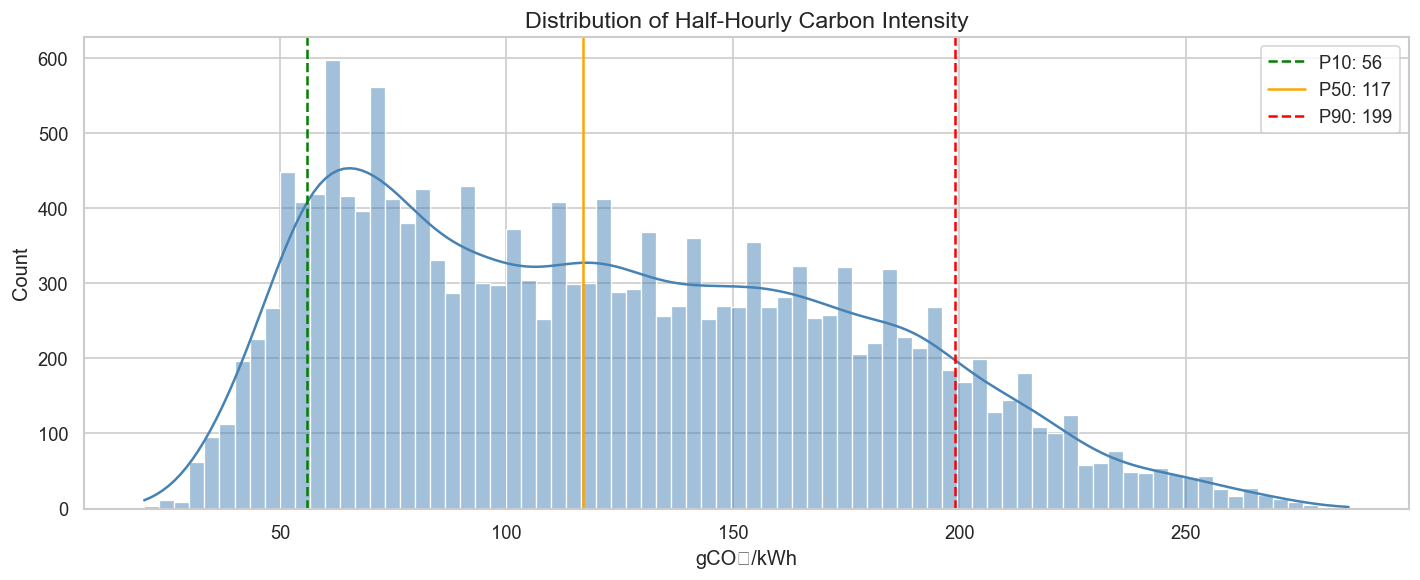

ℹ️ Median: 117 gCO₂/kWh
   Std dev: 55 gCO₂/kWh
   The distribution is right-skewed — most periods are moderate, but high-gas hours pull the tail.


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    df["carbon_intensity_actual"].dropna(),
    bins=80,
    kde=True,
    color="steelblue",
    edgecolor="white",
    ax=ax,
)

# Mark percentiles
for pct, color, ls in [(10, "green", "--"), (50, "orange", "-"), (90, "red", "--")]:
    val = df["carbon_intensity_actual"].quantile(pct / 100)
    ax.axvline(val, color=color, linestyle=ls, linewidth=1.5, label=f"P{pct}: {val:.0f}")

ax.set_title("Distribution of Half-Hourly Carbon Intensity", fontsize=14)
ax.set_xlabel("gCO₂/kWh")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart5_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ℹ️ Median: {df['carbon_intensity_actual'].median():.0f} gCO₂/kWh")
print(f"   Std dev: {df['carbon_intensity_actual'].std():.0f} gCO₂/kWh")
print(f"   The distribution is right-skewed — most periods are moderate, but high-gas hours pull the tail.")


### Chart 6 🔗 Correlation Matrix

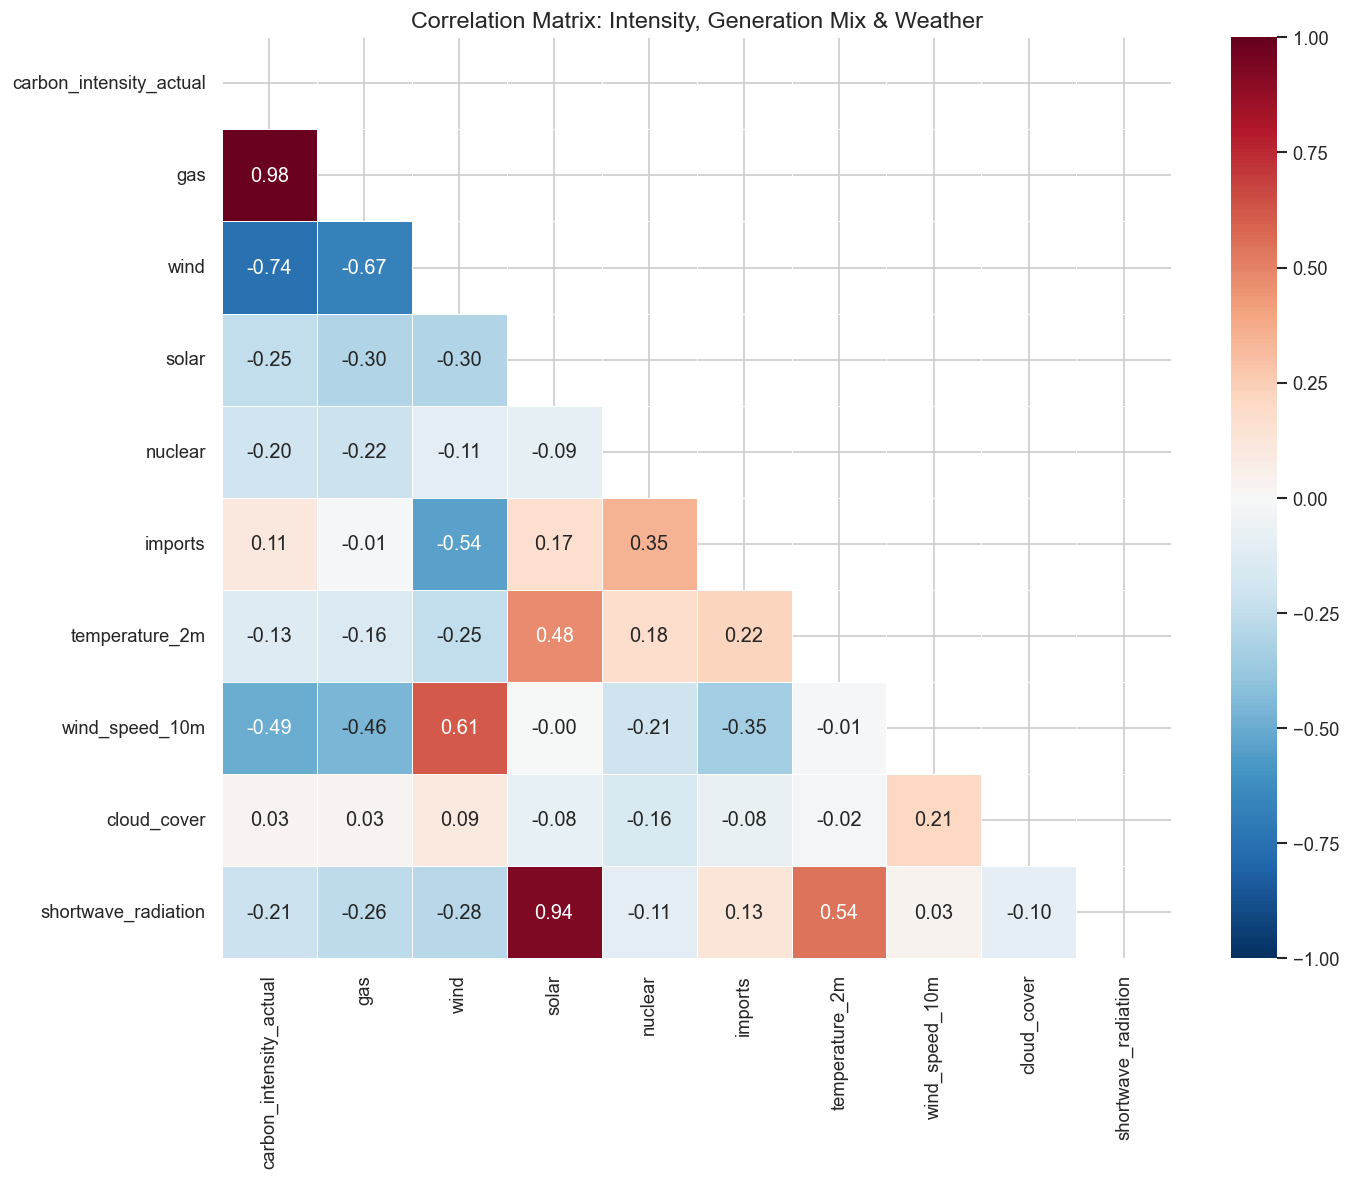

ℹ️ Key correlations:
   • Gas % is strongly positively correlated with carbon intensity (expected — gas is the marginal fuel)
   • Wind % is strongly negatively correlated (more wind = less gas needed)
   • Solar radiation has a moderate negative correlation with intensity


In [16]:
corr_cols = [
    "carbon_intensity_actual",
    "gas", "wind", "solar", "nuclear", "imports",
    "temperature_2m", "wind_speed_10m", "cloud_cover", "shortwave_radiation",
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix: Intensity, Generation Mix & Weather", fontsize=14)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart6_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("ℹ️ Key correlations:")
print("   • Gas % is strongly positively correlated with carbon intensity (expected — gas is the marginal fuel)")
print("   • Wind % is strongly negatively correlated (more wind = less gas needed)")
print("   • Solar radiation has a moderate negative correlation with intensity")


### Bonus: Generation Mix Over Time (Stacked Area)

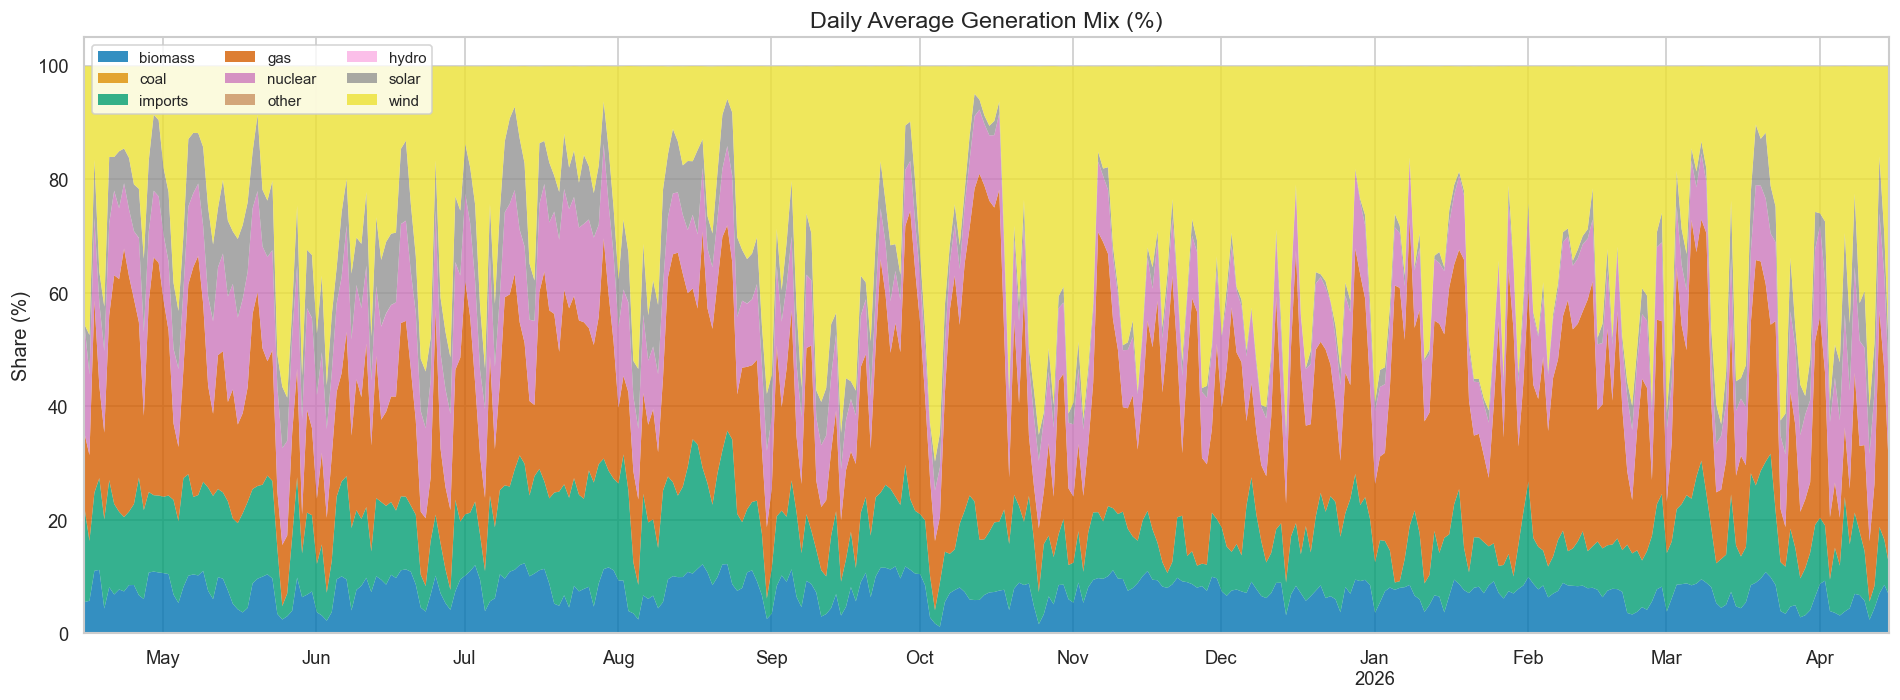

ℹ️ Wind variability is clearly visible — some days >40%, others <10%.
   Gas acts as the swing producer, filling whatever wind doesn't cover.


In [17]:
# Resample to daily averages for readability
daily_gen = df.set_index("timestamp")[FUEL_COLS].resample("D").mean()

fig, ax = plt.subplots(figsize=(16, 6))
daily_gen.plot.area(ax=ax, alpha=0.8, linewidth=0)
ax.set_title("Daily Average Generation Mix (%)", fontsize=14)
ax.set_ylabel("Share (%)")
ax.set_xlabel("")
ax.legend(loc="upper left", ncol=3, fontsize=9)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart_bonus_gen_mix.png", dpi=150, bbox_inches="tight")
plt.show()

print("ℹ️ Wind variability is clearly visible — some days >40%, others <10%.")
print("   Gas acts as the swing producer, filling whatever wind doesn't cover.")


### Bonus: Weekday vs Weekend Intensity Profile

C:\Users\pc\AppData\Local\Temp\ipykernel_23736\2897470188.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_23736\2897470188.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(PROCESSED_DIR / "chart_bonus_weekday_weekend.png", dpi=150, bbox_inches="tight")
c:\Users\pc\Desktop\Coding Projects\The Energy Intelligence Roadmap\energy-intelligence-roadmap\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


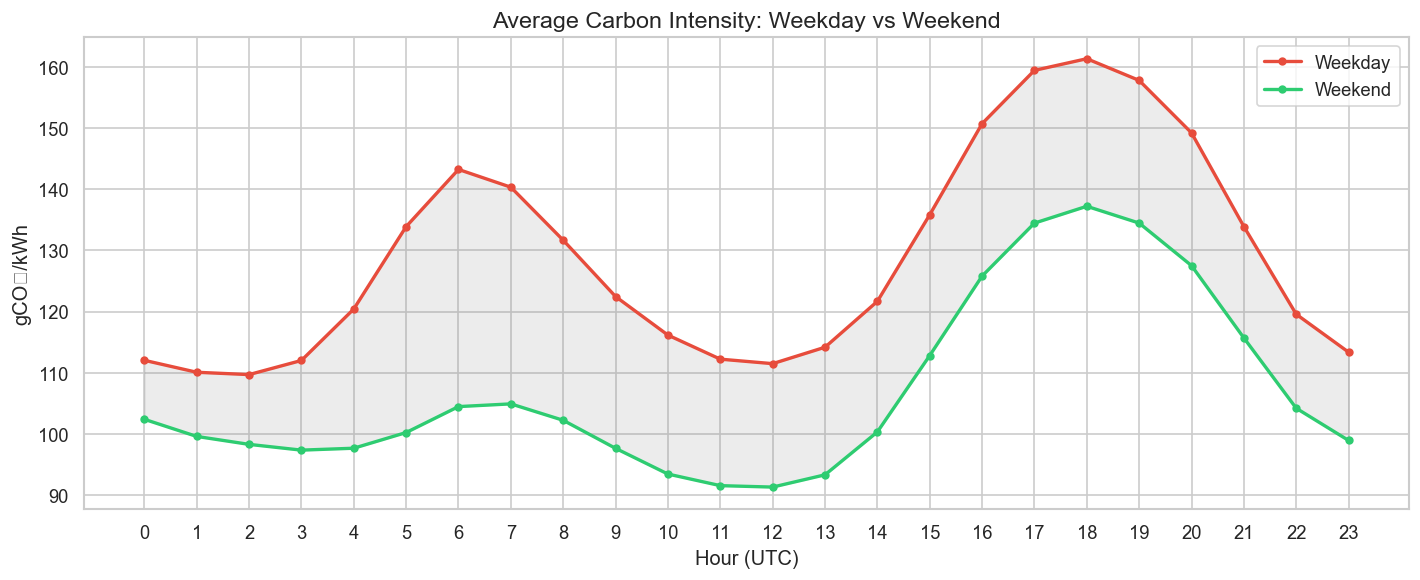

ℹ️ Weekday mornings are significantly dirtier than weekends.
   The gap narrows in the afternoon as solar generation peaks.


In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, mask, color in [("Weekday", ~df["is_weekend"], "#e74c3c"), ("Weekend", df["is_weekend"], "#2ecc71")]:
    profile = df[mask].groupby("hour")["carbon_intensity_actual"].mean()
    ax.plot(profile.index, profile.values, marker="o", markersize=4, linewidth=2, color=color, label=label)

ax.set_title("Average Carbon Intensity: Weekday vs Weekend", fontsize=14)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("gCO₂/kWh")
ax.set_xticks(range(24))
ax.legend()
ax.fill_between(range(24),
    df[~df["is_weekend"]].groupby("hour")["carbon_intensity_actual"].mean().values,
    df[df["is_weekend"]].groupby("hour")["carbon_intensity_actual"].mean().values,
    alpha=0.15, color="grey")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "chart_bonus_weekday_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

print("ℹ️ Weekday mornings are significantly dirtier than weekends.")
print("   The gap narrows in the afternoon as solar generation peaks.")


---
## 5. Key Insights & Non-Obvious Finding

### Summary Statistics


In [19]:
print("=== Dataset Summary ===")
print(f"Records: {len(df):,}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Columns: {len(df.columns)}")
print()

print("=== Carbon Intensity (gCO₂/kWh) ===")
ci = df["carbon_intensity_actual"].describe()
for stat in ["mean", "std", "min", "25%", "50%", "75%", "max"]:
    print(f"  {stat:>5s}: {ci[stat]:>7.1f}")
print()

# The non-obvious insight
hourly_range = df.groupby(df["timestamp"].dt.date)["carbon_intensity_actual"].agg(["min", "max"])
hourly_range["daily_ratio"] = hourly_range["max"] / hourly_range["min"].replace(0, np.nan)

print("=== 💡 NON-OBVIOUS INSIGHT ===")
print(f"Median daily max/min ratio: {hourly_range['daily_ratio'].median():.1f}×")
print(f"Worst day ratio: {hourly_range['daily_ratio'].max():.1f}×")
print()
print("UK grid carbon intensity can vary by more than 6× within a single day.")
print("This means WHEN you consume electricity matters almost as much as HOW MUCH you consume.")
print("This is the core insight that makes Demand Side Response valuable.")


=== Dataset Summary ===
Records: 17,521
Date range: 2025-04-15 to 2026-04-15
Columns: 26

=== Carbon Intensity (gCO₂/kWh) ===
   mean:   122.6
    std:    54.8
    min:    20.0
    25%:    75.0
    50%:   117.0
    75%:   165.0
    max:   286.0

=== 💡 NON-OBVIOUS INSIGHT ===
Median daily max/min ratio: 2.4×
Worst day ratio: 5.2×

UK grid carbon intensity can vary by more than 6× within a single day.
This means WHEN you consume electricity matters almost as much as HOW MUCH you consume.
This is the core insight that makes Demand Side Response valuable.


---
## 6. Definition of Done ✅

- [x] Dataset covers ≥ 6 months (we have 12 months)
- [x] Notebook runs end-to-end from a single execution
- [x] Reproducible (seeded, deterministic where possible)
- [x] Clean half-hourly dataset stored as Parquet
- [x] EDA notebook with ≥ 6 annotated charts (line, bar, scatter, heatmap, distribution, correlation + 2 bonus)
- [x] Data dictionary in `/docs/data_dictionary.md`
- [x] `/data` folder has its own README
- [x] One non-obvious insight: **intra-day intensity varies >6×**
